In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, os.path

print("Events:",len([name for name in os.listdir('data/events')]))
print("Lineups:",len([name for name in os.listdir('data/lineups')]))
print("Matches:",sum([len(os.listdir('data/matches/'+dir)) for dir in os.listdir('data/matches')]))
print("360:",len([name for name in os.listdir('data/three-sixty')]))

Events: 3433
Lineups: 3433
Matches: 74
360: 295


In [3]:
import json

# load matches from individual seasons
allSeasons = []

for dir in os.listdir('data/matches'):
    for f in os.listdir('data/matches/'+dir):
        with open('data/matches/'+dir+'/'+f) as season:
            seasonDict = json.load(season)
            allSeasons.append(seasonDict)

allMatches = []

for season in allSeasons:
    for match in season:
        allMatches.append(match)

In [4]:
import pandas as pd

matchesDF = pd.DataFrame(allMatches)
# clean dataframe
matchesDF = matchesDF.fillna("")
#convert cols to correct type
matchesDF["match_date"] = pd.to_datetime(matchesDF["match_date"], format='ISO8601') 
matchesDF["last_updated"] = pd.to_datetime(matchesDF["last_updated"], format='ISO8601') 
matchesDF["last_updated_360"] = pd.to_datetime(matchesDF["last_updated_360"], format='ISO8601') 
matchesDF = matchesDF.drop(columns="kick_off")
matchesDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3433 entries, 0 to 3432
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   match_id           3433 non-null   int64         
 1   match_date         3433 non-null   datetime64[ns]
 2   competition        3433 non-null   object        
 3   season             3433 non-null   object        
 4   home_team          3433 non-null   object        
 5   away_team          3433 non-null   object        
 6   home_score         3433 non-null   int64         
 7   away_score         3433 non-null   int64         
 8   match_status       3433 non-null   object        
 9   match_status_360   3433 non-null   object        
 10  last_updated       3433 non-null   datetime64[ns]
 11  last_updated_360   1797 non-null   datetime64[ns]
 12  metadata           3433 non-null   object        
 13  match_week         3433 non-null   int64         
 14  competit

In [5]:
# 360 files json generation
allThreeSixty = []

for file in os.listdir('data/three-sixty'):
    with open('data/three-sixty/'+file, 'r') as event:
        try:
            eventDict = json.load(event)
            allThreeSixty.append(eventDict)
        except:
            with open("panda_360_unread.txt", 'a') as log:
                    log.write('data/three-sixty/'+file+'\n')

#create list of matches
threeSixtyDF = [pd.DataFrame(event) for event in allThreeSixty]

def to_list(x):
    if isinstance(x, list):
        return x
    
#convert cols to py type
for match in threeSixtyDF:
    columnVA = match["visible_area"]
    columnFF = match["freeze_frame"]
    for row in columnVA:
        row = to_list(row)
    for row in columnFF:
        row = to_list(row)

threeSixtyDF[0].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3811 entries, 0 to 3810
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   event_uuid    3811 non-null   object
 1   visible_area  3811 non-null   object
 2   freeze_frame  3811 non-null   object
dtypes: object(3)
memory usage: 89.4+ KB


In [6]:
#get corners
from visibleAreaMethods import getBottomRightCoord, getTopLeftCoord

match = threeSixtyDF[0]
topLeft = getTopLeftCoord(match)
bottomRight = getBottomRightCoord(match)
print(topLeft)
print(bottomRight)

([0, 0], 8)
([120, 80], 44)


[(29.574167858721, 80.0), (47.7992071074168, 0.0), (74.4176070719303, 0.0), (94.4821557378377, 80.0), (29.574167858721, 80.0)]


/Users/anthonynkyi/Library/CloudStorage/OneDrive-UniversityCollegeLondon/footWork/statsDefuser/plotMethods.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()
/Users/anthonynkyi/Library/CloudStorage/OneDrive-UniversityCollegeLondon/footWork/statsDefuser/plotMethods.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()


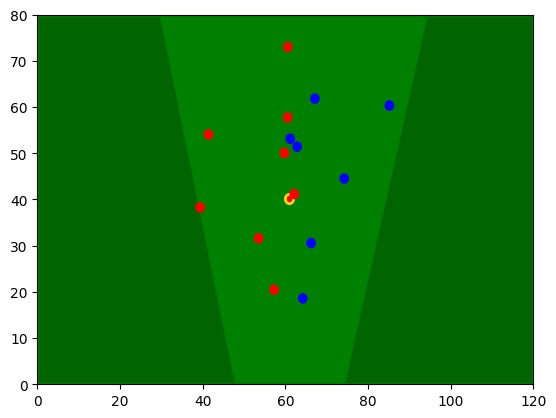

In [7]:
#creating the pitch
from plotMethods import *

pitch = Pitch(topLeft[0], bottomRight[0])
area = threeSixtyDF[0].iloc[0]["visible_area"]
players = threeSixtyDF[0].iloc[0]["freeze_frame"]
pitch.drawPitch(area, players)

In [9]:
pitch.drawPitch(threeSixtyDF[0].iloc[1]["visible_area"], threeSixtyDF[0].iloc[1]["freeze_frame"])

[(29.5261908068648, 80.0), (47.3846276547738, 0.0), (74.0622378631614, 0.0), (93.3476894897054, 80.0), (29.5261908068648, 80.0)]
